In [50]:
from google.colab import files
uploaded = files.upload()

Saving 12.jpg to 12 (1).jpg


In [57]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

In [58]:
def kmeans_from_scratch(data, k=3, max_iter=100):
    centroids = data[np.random.choice(len(data), k, replace=False)]

    for _ in range(max_iter):
        distances = np.linalg.norm(data[:, None] - centroids, axis=2)
        labels = np.argmin(distances, axis=1)

        new_centroids = []
        for i in range(k):
            members = data[labels == i]
            if len(members) == 0:
                new_centroids.append(data[random.randint(0, len(data)-1)])
            else:
                new_centroids.append(members.mean(axis=0))
        new_centroids = np.array(new_centroids)

        if np.allclose(centroids, new_centroids, atol=1e-2):
            break
        centroids = new_centroids

    return labels, centroids

In [59]:
def extract_digit(image_path, k=4):
    image = cv2.imread(image_path)
    img_resized = cv2.resize(image, (300, 300))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    pixels = img_rgb.reshape((-1, 3)).astype(np.float32)
    labels, centers = kmeans_from_scratch(pixels, k)
    clustered = centers[labels].reshape((h, w, 3)).astype(np.uint8)


    counts = np.bincount(labels)
    sorted_cluster_ids = np.argsort(counts)

    digit_mask = None
    for i in sorted_cluster_ids[:2]:
        mask = (labels.reshape((h, w)) == i).astype(np.uint8) * 255
        cleaned = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
        contours, _ = cv2.findContours(cleaned, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        area = sum(cv2.contourArea(c) for c in contours)
        if area > 500:
            digit_mask = cleaned
            break

    if digit_mask is None:
        print("Digit cluster not found.")
        return

    digit_rgb = np.zeros_like(img_rgb)

    digit_rgb[digit_mask == 255] = [0, 255, 0]

    digit_rgb[digit_mask == 0] = [0, 0, 0]

    combined = np.hstack((img_rgb, digit_rgb))

    plt.figure(figsize=(10, 5))
    plt.imshow(combined)
    plt.title("Original vs Digit Extracted")
    plt.axis('off')
    plt.show()

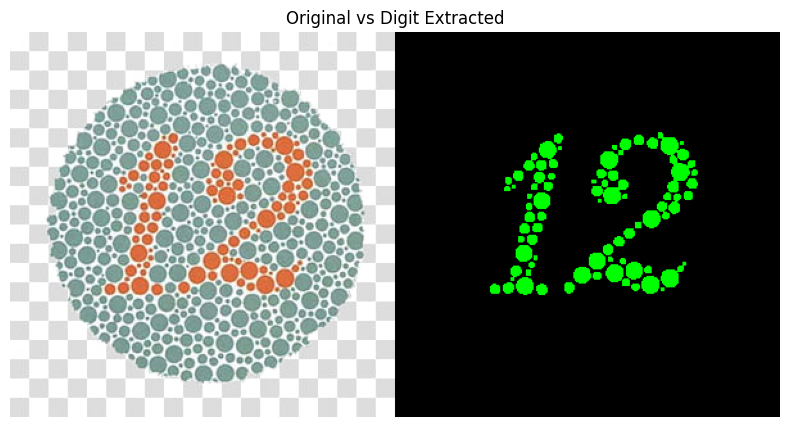

In [60]:
extract_digit("12.jpg", k=4)